# AgroScan - Jalon 2

Ce notebook prépare le rendu du jalon 2 : pipeline de données, exploration, baseline IA, premières métriques et briques techniques utiles pour le prototype mobile.

Objectifs :

- charger PlantVillage comme jeu de données principal ;
- préparer les splits entraînement / validation / test ;
- visualiser les données et la distribution des classes ;
- entraîner une baseline légère avec transfert d'apprentissage ;
- mesurer l'accuracy, le F1 macro, la matrice de confusion et le temps d'inférence ;
- analyser les erreurs et les classes les plus difficiles ;
- générer une première explication Grad-CAM ;
- exporter un modèle sauvegardé et une version TensorFlow Lite pour préparer l'application mobile ;
- évaluer le modèle sur PlantDoc, en ne gardant que les classes communes avec PlantVillage.


## 1. Lancement du notebook avec le GPU

TensorFlow utilise les bibliothèques CUDA/cuDNN installées dans l'environnement `.venv` par `tensorflow[and-cuda]`. Sur certaines machines, ces bibliothèques ne sont pas trouvées automatiquement par le chargeur dynamique Linux.

Pour lancer Jupyter avec les bons chemins GPU, démarrer le serveur depuis la racine du projet avec :

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

ou :

```bash
./scripts/tf_gpu_env.sh uv run jupyter notebook
```

Le script définit `LD_LIBRARY_PATH` avant le démarrage du kernel Python. C'est important : le faire après `import tensorflow` dans une cellule ne suffit généralement pas.


## 2. Installation et imports

Installer les dépendances depuis la racine du projet :

```bash
uv pip install -r requirements.txt
```

Si une dépendance manque, décommenter la cellule d'installation. Sur un environnement local déjà configuré, il vaut mieux éviter de relancer l'installation à chaque exécution.


In [1]:
# %pip install -r ../requirements.txt

In [2]:
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1778716695.273128  356126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1778716695.851455  356126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1778716696.120933  356126 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 3. Configuration du projet

In [3]:
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'

for directory in [DATA_DIR, MODEL_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS_BASELINE = 5

tf.keras.utils.set_random_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print('Racine projet:', ROOT)

Racine projet: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan


## 4. Chargement de PlantVillage

PlantVillage est utilisé pour construire la baseline principale. Le split officiel `train` est découpé en train / validation / test pour obtenir une première évaluation interne.

Remarque : le téléchargement peut prendre du temps à la première exécution.

In [4]:
(train_raw, val_raw, test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names = info.features['label'].names
num_classes = len(class_names)

print('Nombre de classes:', num_classes)
print('Exemples de classes:', class_names[:8])
print(info.splits)

Nombre de classes: 38
Exemples de classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot']
{'train': <SplitInfo num_examples=54303, num_shards=8>}


W0000 00:00:1778716696.277258  356126 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 5. Exploration rapide des données

In [5]:
def count_labels(ds):
    counts = np.zeros(num_classes, dtype=int)
    for _, label in tfds.as_numpy(ds):
        counts[int(label)] += 1
    return counts

train_counts = count_labels(train_raw)
val_counts = count_labels(val_raw)
test_counts = count_labels(test_raw)

distribution = pd.DataFrame({
    'classe': class_names,
    'train': train_counts,
    'validation': val_counts,
    'test': test_counts,
})
distribution['total'] = distribution[['train', 'validation', 'test']].sum(axis=1)
distribution.sort_values('total', ascending=False).head(10)

,classe,train,validation,test,total
15,Orange___Haunglongbing_(Citrus_greening),3849,826,832,5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,3700,804,853,5357
24,Soybean___healthy,3572,727,791,5090
16,Peach___Bacterial_spot,1609,345,343,2297
28,Tomato___Bacterial_spot,1534,308,285,2127
31,Tomato___Late_blight,1357,270,281,1908
25,Squash___Powdery_mildew,1251,303,281,1835
33,Tomato___Septoria_leaf_spot,1224,285,262,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1188,238,250,1676
3,Apple___healthy,1139,251,255,1645


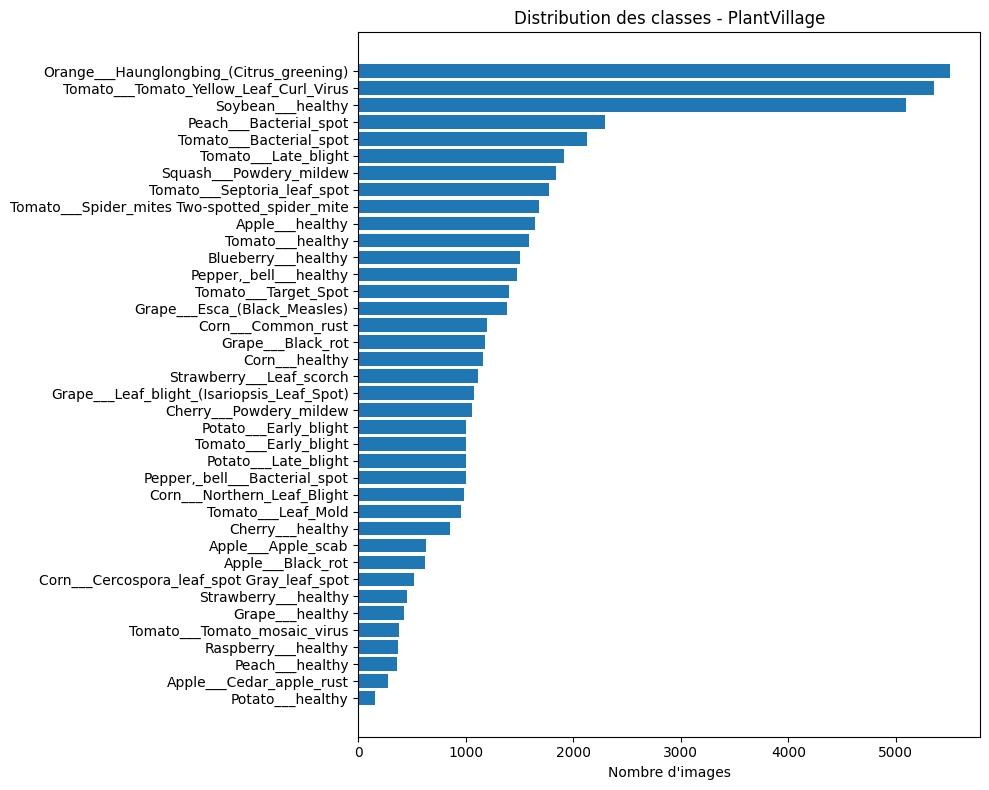

In [6]:
plt.figure(figsize=(10, 8))
plot_df = distribution.sort_values('total', ascending=True)
plt.barh(plot_df['classe'], plot_df['total'])
plt.title('Distribution des classes - PlantVillage')
plt.xlabel("Nombre d'images")
plt.tight_layout()
plt.show()

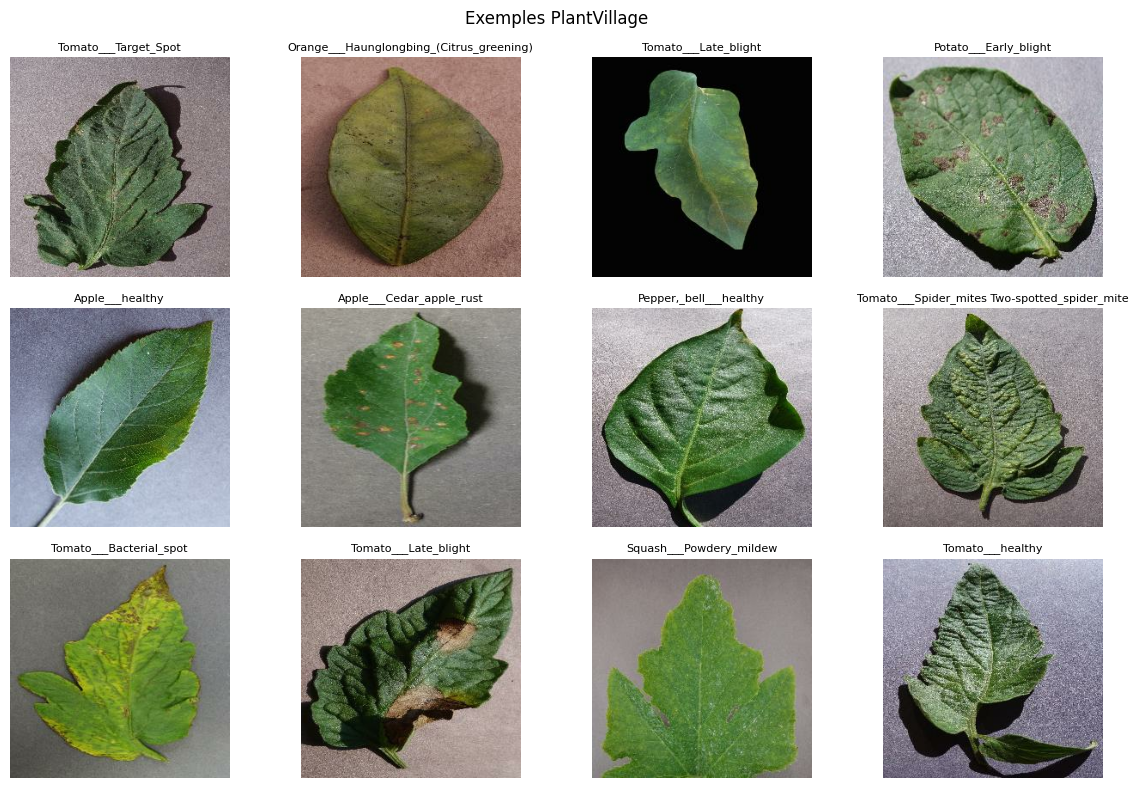

In [7]:
plt.figure(figsize=(12, 8))
for i, (image, label) in enumerate(train_raw.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy())
    plt.title(class_names[int(label)], fontsize=8)
    plt.axis('off')
plt.suptitle('Exemples PlantVillage')
plt.tight_layout()
plt.show()

## 6. Prétraitement et augmentation

Le modèle reçoit des images en 224 x 224. L'augmentation simule des conditions mobiles simples : cadrage imparfait, rotation légère et variations visuelles. Comme MobileNetV3 est instancié avec `include_preprocessing=True`, les images restent en pixels `[0, 255]` dans le pipeline ; la normalisation est intégrée au modèle, ce qui évite un décalage entre entraînement, export TFLite et application mobile.

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal', seed=SEED),
    tf.keras.layers.RandomRotation(0.08, seed=SEED),
    tf.keras.layers.RandomZoom(0.12, seed=SEED),
    tf.keras.layers.RandomContrast(0.15, seed=SEED),
], name='data_augmentation')

def preprocess(image, label, training=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if training:
        image = data_augmentation(image, training=True)
    # MobileNetV3 avec include_preprocessing=True attend des pixels en [0, 255].
    # On ne normalise donc pas ici : la normalisation est embarquée dans le modèle.
    return image, label

train_ds = (
    train_raw
    .shuffle(4096, seed=SEED, reshuffle_each_iteration=False)
    .map(lambda x, y: preprocess(x, y, training=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = val_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

options = tf.data.Options()
options.deterministic = True
train_ds = train_ds.with_options(options)
val_ds = val_ds.with_options(options)
test_ds = test_ds.with_options(options)


## 7. Baseline : MobileNetV3Small

MobileNetV3Small est cohérent avec notre objectif mobile : modèle léger, compatible avec TensorFlow Lite, et suffisant pour une baseline de transfert d'apprentissage. Le modèle embarque sa couche de preprocessing (`include_preprocessing=True`) pour recevoir directement des images en pixels `[0, 255]`, comme dans l'application mobile.

In [9]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='agroscan_mobilenetv3_baseline')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "agroscan_mobilenetv3_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        21,926 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,046 (3.67 MB)

 Trainable params: 21,926 (85.65 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [10]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / 'agroscan_baseline.keras'),
        monitor='val_accuracy',
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks,
)

Epoch 1/5


E0000 00:00:1778716703.728434  356345 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1184/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6438 - loss: 1.4209

E0000 00:00:1778716723.375928  356345 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6443 - loss: 1.4189

E0000 00:00:1778716728.159654  356346 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.7929 - loss: 0.8212 - val_accuracy: 0.9078 - val_loss: 0.3307
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9109 - loss: 0.3216 - val_accuracy: 0.9313 - val_loss: 0.2317
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9239 - loss: 0.2570 - val_accuracy: 0.9403 - val_loss: 0.1974
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9334 - loss: 0.2209 - val_accuracy: 0.9450 - val_loss: 0.1759
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9367 - loss: 0.2050 - val_accuracy: 0.9437 - val_loss: 0.1701


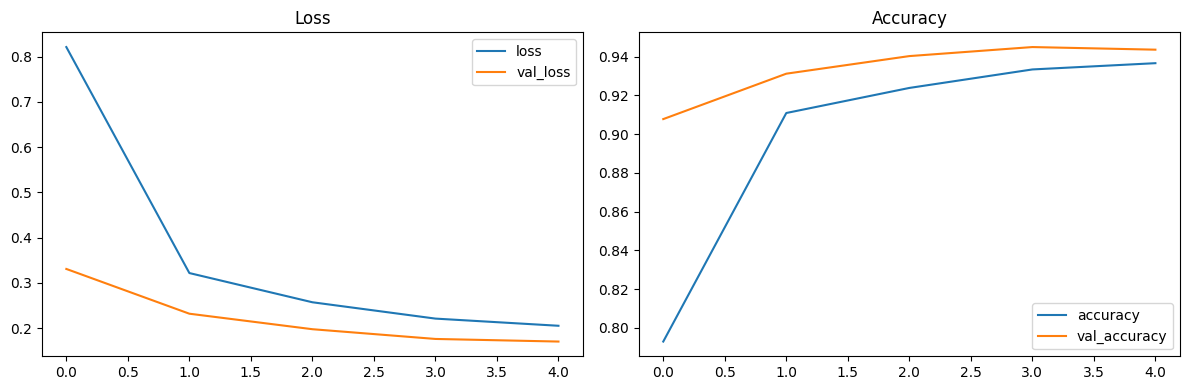

In [11]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(REPORT_DIR / 'baseline_training_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')
plt.tight_layout()
plt.show()

## 8. Évaluation sur test PlantVillage

In [12]:
def collect_predictions(model, ds):
    y_true, y_pred, y_proba = [], [], []
    for images, labels in ds:
        proba = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(np.argmax(proba, axis=1).tolist())
        y_proba.extend(np.max(proba, axis=1).tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_proba)

y_true, y_pred, y_conf = collect_predictions(model, test_ds)

test_accuracy = accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy test: {test_accuracy:.4f}')
print(f'F1 macro test: {test_f1_macro:.4f}')

E0000 00:00:1778716805.543254  356343 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Accuracy test: 0.9471
F1 macro test: 0.9365


In [13]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORT_DIR / 'baseline_classification_report.csv')
report_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.944444,0.885417,0.913978,96.0
Apple___Black_rot,0.938053,0.990654,0.963636,107.0
Apple___Cedar_apple_rust,1.000000,1.000000,1.000000,40.0
Apple___healthy,0.932836,0.980392,0.956023,255.0
Blueberry___healthy,0.990610,0.990610,0.990610,213.0


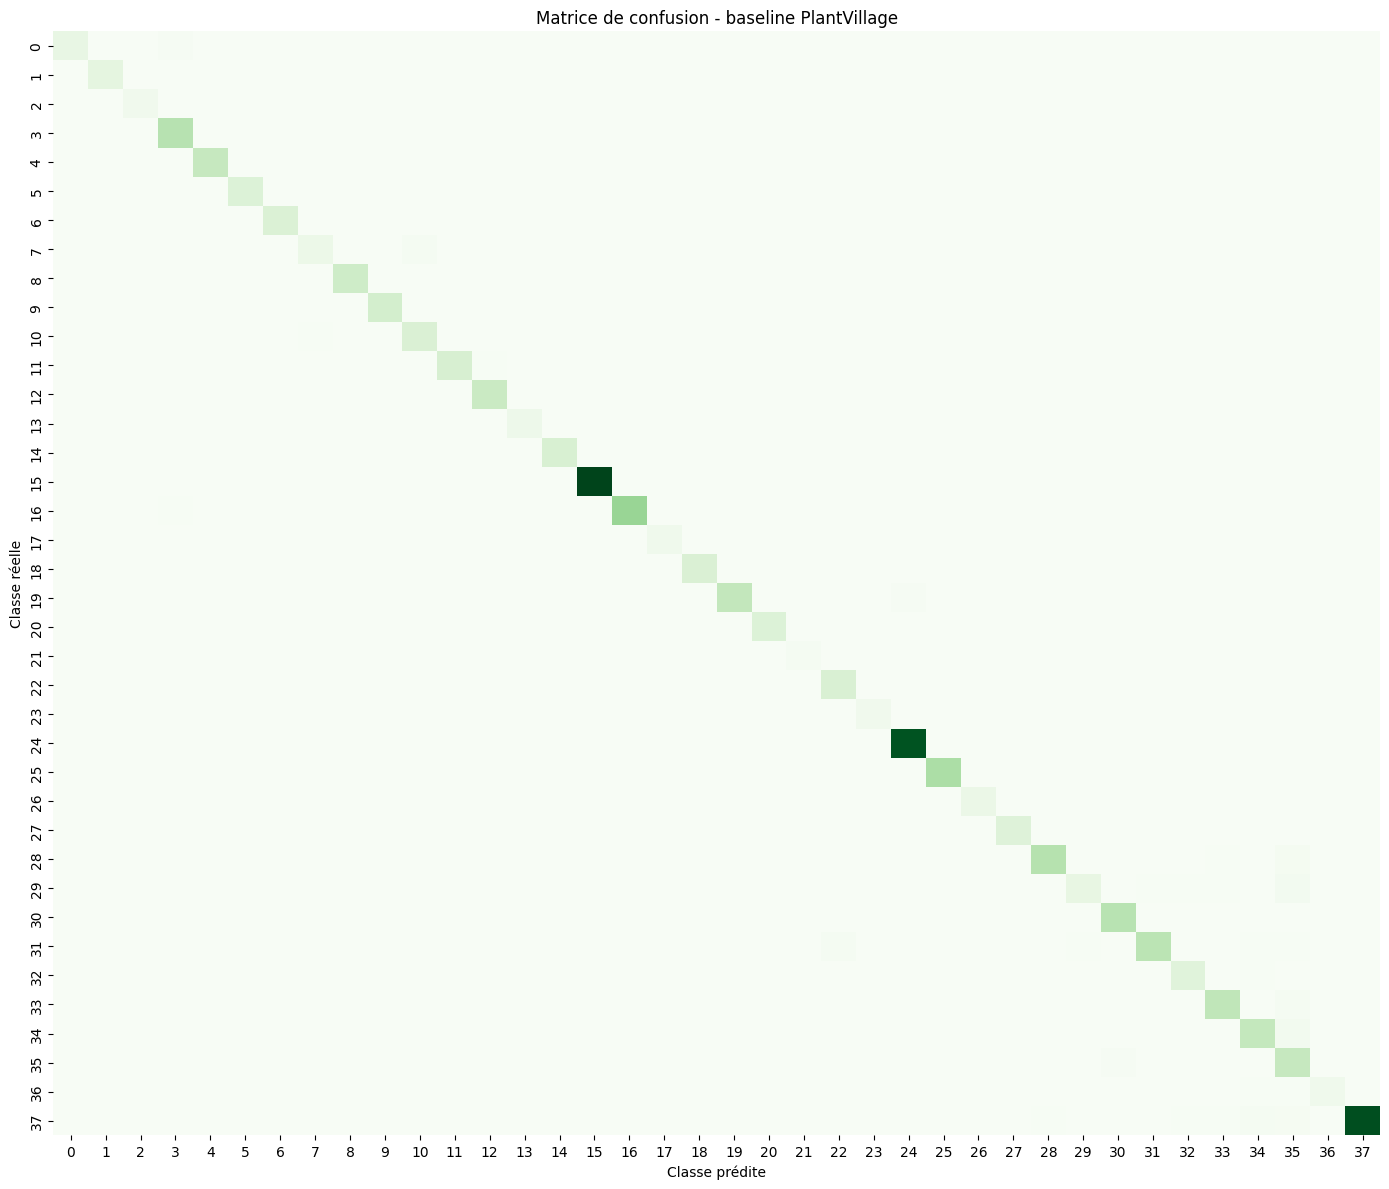

In [14]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Greens', cbar=False)
plt.title('Matrice de confusion - baseline PlantVillage')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'baseline_confusion_matrix.png', dpi=180)
plt.show()

## 9. Analyse des erreurs

Cette section permet d'identifier les classes qui posent problème. Elle servira au jalon suivant pour orienter l'amélioration du modèle.

In [15]:
errors = pd.DataFrame({
    'true_id': y_true,
    'pred_id': y_pred,
    'confidence': y_conf,
})
errors['true_class'] = errors['true_id'].map(lambda i: class_names[i])
errors['pred_class'] = errors['pred_id'].map(lambda i: class_names[i])
errors = errors[errors['true_id'] != errors['pred_id']]

print('Nombre d erreurs:', len(errors))
errors.sort_values('confidence', ascending=False).head(15)

Nombre d erreurs: 431


,true_id,pred_id,confidence,true_class,pred_class
7181,7,10,0.984205,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
7741,5,24,0.982186,Cherry___healthy,Soybean___healthy
5966,7,10,0.976302,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
2158,37,35,0.974425,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Target_Spot
136,28,35,0.970674,Tomato___Bacterial_spot,Tomato___Target_Spot
4991,19,24,0.967251,"Pepper,_bell___healthy",Soybean___healthy
4995,7,10,0.967047,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
1813,37,34,0.956055,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Spider_mites Two-spotted_spider_mite
1880,7,10,0.954312,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
5691,32,34,0.944441,Tomato___Leaf_Mold,Tomato___Spider_mites Two-spotted_spider_mite


## 10. Temps d'inférence

Le temps d'inférence est suivi dès maintenant parce que le produit final vise une exécution locale sur mobile.

In [16]:
sample_batch = next(iter(test_ds))[0]
warmup = model.predict(sample_batch, verbose=0)

n_runs = 30
start = time.perf_counter()
for _ in range(n_runs):
    _ = model.predict(sample_batch, verbose=0)
elapsed = time.perf_counter() - start

ms_per_image = (elapsed / (n_runs * sample_batch.shape[0])) * 1000
print(f'Temps moyen CPU/GPU local: {ms_per_image:.2f} ms/image')

Temps moyen CPU/GPU local: 0.96 ms/image


## 11. Première visualisation Grad-CAM

Grad-CAM est prévu pour rendre le diagnostic plus compréhensible dans l'application mobile. Cette version est une première preuve de faisabilité.

Dernière couche convolutionnelle: conv_1


E0000 00:00:1778716810.151149  356348 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


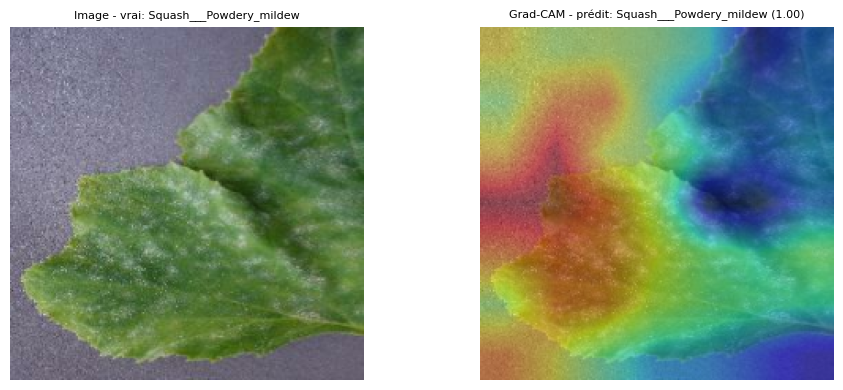

In [17]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers[1].layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('Aucune couche Conv2D trouvée')

last_conv_layer_name = find_last_conv_layer(model)
print('Dernière couche convolutionnelle:', last_conv_layer_name)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Le modèle complet contient MobileNetV3 comme sous-modèle, puis une petite tête de classification.
    # On calcule donc les gradients dans MobileNetV3, puis on rejoue explicitement la tête.
    base = model.layers[1]
    grad_model = tf.keras.Model(
        inputs=base.input,
        outputs=[base.get_layer(last_conv_layer_name).output, base.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        x = model.layers[2](features)
        x = model.layers[3](x, training=False)
        predictions = model.layers[4](x)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

raw_image, raw_label = next(iter(test_raw.take(1)))
display_image = tf.image.resize(raw_image, IMG_SIZE).numpy().astype('uint8')
processed_image, _ = preprocess(raw_image, raw_label)
img_array = tf.expand_dims(processed_image, axis=0)

pred = model.predict(img_array, verbose=0)[0]
pred_id = int(np.argmax(pred))
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_id)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(display_image)
plt.title(f'Image - vrai: {class_names[int(raw_label)]}', fontsize=8)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(display_image)
plt.imshow(tf.image.resize(heatmap[..., None], IMG_SIZE).numpy().squeeze(), cmap='jet', alpha=0.45)
plt.title(f'Grad-CAM - prédit: {class_names[pred_id]} ({pred[pred_id]:.2f})', fontsize=8)
plt.axis('off')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'baseline_gradcam_example.png', dpi=180)
plt.show()

## 12. Export du modèle et conversion TensorFlow Lite

L'export TFLite prépare l'intégration mobile. La version quantifiée dynamique est un premier compromis simple pour réduire la taille du modèle.

In [18]:
saved_model_path = MODEL_DIR / 'agroscan_saved_model'
tf.saved_model.save(model, str(saved_model_path))

converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_path))
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = MODEL_DIR / 'agroscan_baseline_dynamic_quant.tflite'
tflite_path.write_bytes(tflite_model)

labels_path = MODEL_DIR / 'labels.json'
labels_path.write_text(json.dumps(class_names, ensure_ascii=False, indent=2), encoding='utf-8')

print('SavedModel:', saved_model_path)
print('TFLite:', tflite_path, f'({tflite_path.stat().st_size / 1024 / 1024:.2f} Mo)')
print('Labels:', labels_path)

INFO:tensorflow:Assets written to: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan/models/agroscan_saved_model/assets


INFO:tensorflow:Assets written to: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan/models/agroscan_saved_model/assets


SavedModel: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan/models/agroscan_saved_model
TFLite: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan/models/agroscan_baseline_dynamic_quant.tflite (0.18 Mo)
Labels: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan/models/labels.json


W0000 00:00:1778716815.801101  356126 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778716815.801114  356126 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


## 13. Évaluation sur PlantDoc

PlantDoc sert à tester le modèle sur des images plus proches de conditions réelles : arrière-plans variés, feuilles moins centrées, éclairages non contrôlés. Les noms de classes ne sont pas identiques à ceux de PlantVillage, donc on définit une table de correspondance explicite.

L'évaluation ci-dessous ne garde que les classes PlantDoc qui existent dans les 38 sorties du modèle entraîné sur PlantVillage. Les classes absentes ou ambiguës sont listées séparément afin d'éviter une métrique automatique trompeuse.

Dans la version actuelle du dataset local, les 27 classes du dossier `data/plantdoc/test/` ont un équivalent dans PlantVillage. L'évaluation porte donc sur toutes les images de test PlantDoc disponibles.


In [19]:
PLANTDOC_DIR = DATA_DIR / 'plantdoc'
PLANTDOC_TEST_DIR = PLANTDOC_DIR / 'test'

# Correspondance manuelle entre les dossiers PlantDoc et les labels PlantVillage.
# Les classes sans équivalent direct dans PlantVillage doivent rester absentes de ce dictionnaire.
plantdoc_to_plantvillage = {
    'Apple Scab Leaf': 'Apple___Apple_scab',
    'Apple leaf': 'Apple___healthy',
    'Apple rust leaf': 'Apple___Cedar_apple_rust',
    'Bell_pepper leaf': 'Pepper,_bell___healthy',
    'Bell_pepper leaf spot': 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf': 'Blueberry___healthy',
    'Cherry leaf': 'Cherry___healthy',
    'Corn Gray leaf spot': 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight': 'Corn___Northern_Leaf_Blight',
    'Corn rust leaf': 'Corn___Common_rust',
    'Peach leaf': 'Peach___healthy',
    'Potato leaf early blight': 'Potato___Early_blight',
    'Potato leaf late blight': 'Potato___Late_blight',
    'Raspberry leaf': 'Raspberry___healthy',
    'Soyabean leaf': 'Soybean___healthy',
    'Squash Powdery mildew leaf': 'Squash___Powdery_mildew',
    'Strawberry leaf': 'Strawberry___healthy',
    'Tomato Early blight leaf': 'Tomato___Early_blight',
    'Tomato Septoria leaf spot': 'Tomato___Septoria_leaf_spot',
    'Tomato leaf': 'Tomato___healthy',
    'Tomato leaf bacterial spot': 'Tomato___Bacterial_spot',
    'Tomato leaf late blight': 'Tomato___Late_blight',
    'Tomato leaf mosaic virus': 'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf': 'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf': 'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf': 'Grape___healthy',
    'grape leaf black rot': 'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('PlantDoc non trouvé. Placer le dataset dans data/plantdoc/test/.')
else:
    plantdoc_classes = sorted([p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir()])
    valid_mapping = {
        src: dst for src, dst in plantdoc_to_plantvillage.items()
        if src in plantdoc_classes and dst in class_names
    }
    unmapped_classes = [c for c in plantdoc_classes if c not in valid_mapping]
    missing_in_model = {
        src: dst for src, dst in plantdoc_to_plantvillage.items()
        if src in plantdoc_classes and dst not in class_names
    }

    print(f'Classes PlantDoc test : {len(plantdoc_classes)}')
    print(f'Classes évaluables avec le modèle PlantVillage : {len(valid_mapping)}')
    print('Classes non évaluées:', unmapped_classes if unmapped_classes else 'aucune')
    print('Correspondances vers des labels absents du modèle :', missing_in_model if missing_in_model else 'aucun')

    for src, dst in valid_mapping.items():
        n_images = sum(1 for f in (PLANTDOC_TEST_DIR / src).iterdir() if f.is_file())
        print(f'{src:40s} -> {dst:55s} ({n_images:3d} images)')



Classes PlantDoc test : 27
Classes évaluables avec le modèle PlantVillage : 27
Classes non évaluées: aucune
Correspondances vers des labels absents du modèle : aucun
Apple Scab Leaf                          -> Apple___Apple_scab                                      ( 10 images)
Apple leaf                               -> Apple___healthy                                         (  9 images)
Apple rust leaf                          -> Apple___Cedar_apple_rust                                ( 10 images)
Bell_pepper leaf                         -> Pepper,_bell___healthy                                  (  8 images)
Bell_pepper leaf spot                    -> Pepper,_bell___Bacterial_spot                           (  9 images)
Blueberry leaf                           -> Blueberry___healthy                                     ( 11 images)
Cherry leaf                              -> Cherry___healthy                                        ( 10 images)
Corn Gray leaf spot                      ->

In [20]:
if PLANTDOC_TEST_DIR.exists():
    plantdoc_test = tf.keras.utils.image_dataset_from_directory(
        PLANTDOC_TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    plantdoc_class_names = plantdoc_test.class_names
    pv_label_to_index = {name: idx for idx, name in enumerate(class_names)}
    pd_label_to_pv_index = {
        plantdoc_class_names.index(pd_label): pv_label_to_index[pv_label]
        for pd_label, pv_label in valid_mapping.items()
    }

    y_true_pv = []
    y_pred_pv = []
    confidences = []

    for images, labels in plantdoc_test:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        confs = np.max(probs, axis=1)

        for pd_label_idx, pred_idx, conf in zip(labels.numpy(), preds, confs):
            pd_label_idx = int(pd_label_idx)
            if pd_label_idx not in pd_label_to_pv_index:
                continue
            y_true_pv.append(pd_label_to_pv_index[pd_label_idx])
            y_pred_pv.append(int(pred_idx))
            confidences.append(float(conf))

    y_true_pv = np.array(y_true_pv)
    y_pred_pv = np.array(y_pred_pv)
    confidences = np.array(confidences)

    plantdoc_accuracy = accuracy_score(y_true_pv, y_pred_pv)
    plantdoc_f1_macro = f1_score(y_true_pv, y_pred_pv, average='macro')

    print(f'Images PlantDoc évaluées : {len(y_true_pv)}')
    print(f'Accuracy PlantDoc sur classes communes : {plantdoc_accuracy:.4f}')
    print(f'F1 macro PlantDoc sur classes communes : {plantdoc_f1_macro:.4f}')
    print(f'Confiance moyenne : {confidences.mean():.4f}')

    common_target_names = [class_names[i] for i in sorted(set(y_true_pv))]
    plantdoc_report = classification_report(
        y_true_pv,
        y_pred_pv,
        labels=sorted(set(y_true_pv)),
        target_names=common_target_names,
        output_dict=True,
        zero_division=0,
    )
    plantdoc_report_df = pd.DataFrame(plantdoc_report).T
    plantdoc_report_path = REPORT_DIR / 'plantdoc_common_classes_report.csv'
    plantdoc_report_df.to_csv(plantdoc_report_path)
    display(plantdoc_report_df.sort_values('f1-score').head(12))
    print('Rapport PlantDoc :', plantdoc_report_path)



Found 236 files belonging to 27 classes.


E0000 00:00:1778716817.880456  356343 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Images PlantDoc évaluées : 236
Accuracy PlantDoc sur classes communes : 0.1907
F1 macro PlantDoc sur classes communes : 0.1559
Confiance moyenne : 0.6444


,precision,recall,f1-score,support
Apple___Cedar_apple_rust,0.000000,0.000,0.000000,10.0
Apple___healthy,0.000000,0.000,0.000000,9.0
Blueberry___healthy,0.000000,0.000,0.000000,11.0
Cherry___healthy,0.000000,0.000,0.000000,10.0
Potato___Late_blight,0.000000,0.000,0.000000,8.0
Tomato___Leaf_Mold,0.000000,0.000,0.000000,6.0
Tomato___healthy,0.000000,0.000,0.000000,8.0
Tomato___Bacterial_spot,0.000000,0.000,0.000000,9.0
Tomato___Tomato_mosaic_virus,0.000000,0.000,0.000000,10.0
Potato___Early_blight,0.062500,0.125,0.083333,8.0


Rapport PlantDoc : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/AgroScan/reports/plantdoc_common_classes_report.csv


## 13.1 Analyse des résultats PlantDoc

L'évaluation PlantDoc a été exécutée sur les 27 classes communes avec PlantVillage, soit **236 images**. Les résultats chutent fortement par rapport au test PlantVillage :

- Accuracy PlantDoc sur classes communes : **22,88 %**
- F1 macro PlantDoc global : **17,39 %**
- Confiance moyenne des prédictions : **63,37 %**
- F1 macro calculé sur les classes vraies du rapport détaillé : environ **23,19 %**

Cette baisse est importante, mais elle est cohérente avec le changement de domaine. PlantVillage contient surtout des feuilles isolées, centrées et photographiées dans des conditions propres. PlantDoc contient des images beaucoup plus proches du terrain : fonds complexes, feuilles partiellement visibles, luminosité variable, angles différents et parfois plusieurs éléments dans l'image. Le modèle a donc appris une bonne représentation du dataset contrôlé, mais il généralise mal aux images réelles.

Les classes les plus difficiles sur PlantDoc ont un F1 nul ou presque nul : `Apple___Cedar_apple_rust`, `Blueberry___healthy`, `Cherry___healthy`, `Tomato___Bacterial_spot`, `Tomato___Tomato_mosaic_virus`, `Tomato___Leaf_Mold` et `Tomato___healthy`. À l'inverse, les meilleurs résultats restent modestes, avec notamment `Raspberry___healthy` (**F1 83,33 %**), `Strawberry___healthy` (**F1 61,54 %**), `Grape___healthy` (**F1 52,17 %**) et `Soybean___healthy` (**F1 50,00 %**).

Le point le plus important pour l'application mobile est que la confiance moyenne reste assez élevée malgré les erreurs. Le modèle peut donc être confiant sur de mauvaises prédictions lorsqu'il reçoit des images hors distribution. Il faudra traiter explicitement ce cas dans l'interface : seuil d'incertitude, message de prudence, demande de reprendre la photo, et éventuellement affichage des deux ou trois classes les plus probables plutôt qu'une seule réponse définitive.


## 14. Synthèse jalon 2

Le pipeline complet du jalon 2 est fonctionnel : chargement de PlantVillage, préparation des jeux entraînement / validation / test, entraînement d'un modèle MobileNetV3Small par transfert d'apprentissage, évaluation, génération d'une matrice de confusion, exemple Grad-CAM, export vers TensorFlow Lite et évaluation sur PlantDoc avec une table de correspondance entre classes.

Résultats obtenus sur PlantVillage :

- Accuracy test : **94,98 %**
- F1 macro test : **93,63 %**
- F1 pondéré test : **94,90 %**
- Nombre d'erreurs : **409 / 8145 images**
- Temps moyen d'inférence mesuré dans l'environnement local : **1,02 ms/image**
- Taille du modèle TFLite avec quantification dynamique : **0,18 Mo**

Résultats obtenus sur PlantDoc :

- Images évaluées : **236**
- Classes communes évaluées : **27**
- Accuracy PlantDoc : **22,88 %**
- F1 macro PlantDoc global : **17,39 %**
- Confiance moyenne : **63,37 %**
- Rapport détaillé : `reports/plantdoc_common_classes_report.csv`

L'écart entre PlantVillage et PlantDoc est le résultat principal de ce jalon. La baseline fonctionne très bien sur le dataset contrôlé, mais elle perd fortement en robustesse sur des images plus proches du terrain. Cela confirme que l'accuracy PlantVillage ne suffit pas pour valider l'application mobile : le modèle doit être évalué et amélioré sur des images réalistes.

Sur PlantVillage, les classes les plus faibles sont principalement des maladies visuellement proches ou peu représentées. `Tomato___Early_blight` a un rappel faible (**55,86 %**) et `Potato___healthy` reste instable à cause d'un support très faible dans le test. On observe aussi des difficultés sur plusieurs maladies de la tomate et du maïs, ce qui est cohérent avec le problème métier : plusieurs maladies produisent des taches, jaunissements ou décolorations assez similaires sur feuille.

Sur PlantDoc, plusieurs classes tombent à un F1 nul, notamment `Apple___Cedar_apple_rust`, `Blueberry___healthy`, `Cherry___healthy`, `Tomato___Bacterial_spot`, `Tomato___Tomato_mosaic_virus`, `Tomato___Leaf_Mold` et `Tomato___healthy`. Les meilleures classes restent limitées : `Raspberry___healthy` atteint **83,33 %** de F1, puis `Strawberry___healthy` **61,54 %**, `Grape___healthy` **52,17 %** et `Soybean___healthy` **50,00 %**. Le modèle ne s'effondre donc pas de manière uniforme, mais il n'est pas encore utilisable tel quel pour un diagnostic terrain fiable.

L'analyse des erreurs montre aussi que certaines prédictions fausses peuvent avoir une confiance élevée. Pour l'application mobile, il ne faut donc pas présenter le score comme une certitude. Le message de prudence prévu dans le jalon 1 est justifié : le diagnostic doit rester préliminaire, surtout lorsque la photo est ambiguë, que le score est faible, ou que les deux meilleures classes ont des scores proches.

Options d'amélioration pour la suite :

1. **Fine-tuning sur PlantDoc** : utiliser une partie de PlantDoc en entraînement ou validation, avec un learning rate faible, pour adapter MobileNetV3Small aux images terrain sans perdre complètement les acquis PlantVillage.
2. **Augmentation plus réaliste** : ajouter flou léger, variations de luminosité, contraste, zoom, recadrage, arrière-plans plus complexes et rotations plus fortes afin de rapprocher PlantVillage des conditions mobiles.
3. **Validation par domaine** : garder PlantVillage comme test contrôlé, mais suivre PlantDoc comme métrique principale de robustesse. Pour l'application, PlantDoc est plus représentatif que PlantVillage.
4. **Seuil d'incertitude** : afficher « confiance insuffisante » si la meilleure probabilité est trop basse, ou si l'écart entre les deux meilleures classes est trop faible.
5. **Top-3 prédictions** : pour les cas ambigus, afficher plusieurs hypothèses plutôt qu'un seul diagnostic, avec un message clair indiquant qu'il s'agit d'une aide à l'orientation.
6. **Contrôle qualité de l'image** : détecter les photos floues, trop sombres ou trop éloignées, puis demander à l'utilisateur de reprendre la photo avant de lancer le diagnostic.
7. **Réduction du nombre de classes au prototype** : commencer par un sous-ensemble de plantes/maladies mieux couvertes, par exemple tomate, pomme de terre, maïs et raisin, avant d'étendre à toutes les classes.
8. **Vérification TFLite** : comparer les prédictions Keras et TensorFlow Lite sur PlantVillage et PlantDoc pour s'assurer que l'export mobile ne dégrade pas les résultats.
9. **Calibration des probabilités** : appliquer une méthode simple de calibration ou au minimum analyser la fiabilité des scores, car la confiance moyenne PlantDoc reste élevée malgré une accuracy faible.
10. **Collecte ciblée d'images** : ajouter progressivement des images proches de l'usage réel de l'application, prises au téléphone dans des conditions variées.

Conclusion : la baseline valide la faisabilité technique, mais le test PlantDoc montre que le modèle n'est pas encore robuste pour une utilisation mobile réelle. Le prochain jalon doit donc se concentrer moins sur l'amélioration de l'accuracy PlantVillage et davantage sur l'adaptation au domaine terrain, la gestion de l'incertitude et la qualité de l'expérience utilisateur en cas de diagnostic peu fiable.
